In [ ]:
# Step 0 --- Load and prepare
# This code loads the Telco Customer Churn dataset from a remote source and resolves data-type issues in the 'TotalCharges' column.
# It then maps the categorical 'Churn' target values into a binary numeric format of 0s and 1s to prepare the labels for machine learning tasks.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_bin'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [ ]:
# Step 1 --- Build a feature set with numeric + one-hot encoded categorical
# This code extracts both numeric and one-hot encoded categorical features, then horizontally concatenates them into a unified feature matrix X alongside the target variable y.
# It then prints the structural shape of this final matrix and lists the consolidated feature names to verify that the dataset is properly structured for model training.

num = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
cat = pd.get_dummies(df[['Contract', 'PaymentMethod']], drop_first=True)
X = pd.concat([num, cat], axis=1)
y = df['Churn_bin']
print('X shape:', X.shape)
print('Features:', list(X.columns))

X shape: (7043, 9)
Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
# Step 2 ---  Mutual information scores for all features
# This code calculates mutual information scores to measure the amount of statistical dependency shared between each feature in X and the binary target variable y.
# It then organizes these dependency scores into a sorted Pandas Series, ranking the features from highest to lowest predictive value to help identify the most informative inputs.

from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores.round(4)


,0
tenure,0.0772
Contract_Two year,0.0546
MonthlyCharges,0.0432
TotalCharges,0.0431
PaymentMethod_Electronic check,0.0369
PaymentMethod_Credit card (automatic),0.0169
SeniorCitizen,0.0138
Contract_One year,0.0116
PaymentMethod_Mailed check,0.0008


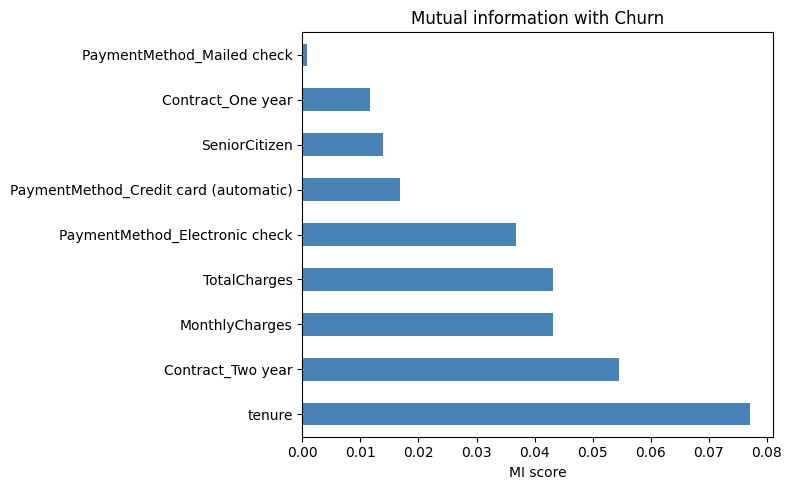

In [ ]:
# Step 3 --- Bar chart of MI scores
# This code generates a horizontal bar chart to visually compare the calculated Mutual Information scores across all extracted features.
# It assists in feature selection by ranking the variables, allowing for a quick identification of the strongest predictors for customer churn.

plt.figure(figsize=(8, 5))
mi_scores.plot(kind='barh', color='steelblue')
plt.title('Mutual information with Churn')
plt.xlabel('MI score')
plt.tight_layout()
plt.show()

In [ ]:
# Step 4 --- RFE — pick the top 3 features
# This code applies Recursive Feature Elimination (RFE) using a Logistic Regression baseline to iteratively prune features down to the top three predictors.
# It then compiles the selection status and importance rankings into a Pandas DataFrame, sorted from most to least relevant, to isolate the optimal feature subset.

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=3)
rfe.fit(X_scaled, y)
result = pd.DataFrame({'feature': X.columns, 'kept': rfe.support_, 'rank': rfe.ranking_})
result.sort_values('rank')


,feature,kept,rank
0,tenure,True,1
1,MonthlyCharges,True,1
5,Contract_Two year,True,1
2,TotalCharges,False,2
4,Contract_One year,False,3
7,PaymentMethod_Electronic check,False,4
3,SeniorCitizen,False,5
8,PaymentMethod_Mailed check,False,6
6,PaymentMethod_Credit card (automatic),False,7


In [12]:
# Step 5 --- Compare accuracy: all features vs top 3
# This code splits the scaled features and labels into training and validation sets to establish a rigorous evaluation baseline.
# It then trains two distinct Logistic Regression models—one using all features and another using only the top three RFE-selected inputs—to compare their classification accuracy.

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
m_all = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print('All features:', round(accuracy_score(y_te, m_all.predict(X_te)), 4))
idx = np.where(rfe.support_)[0]
m_top = LogisticRegression(max_iter=1000).fit(X_tr[:, idx], y_tr)
print('Top 3:', round(accuracy_score(y_te, m_top.predict(X_te[:, idx])), 4))

All features: 0.802
Top 3: 0.8006
